In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
diabetes = load_diabetes()

# Convert to DataFrame
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print(df.head())


        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


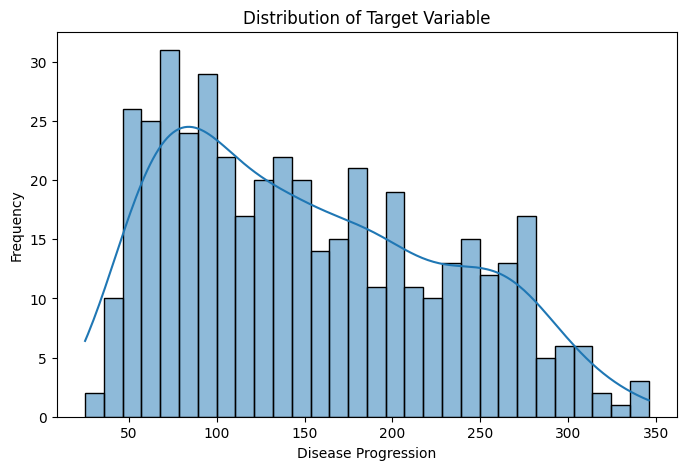

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['target'], bins=30, kde=True)
plt.title("Distribution of Target Variable")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.show()

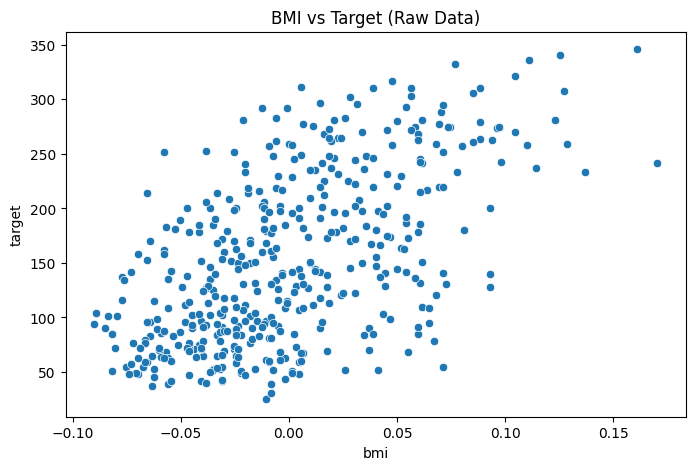

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='target', data=df)
plt.title("BMI vs Target (Raw Data)")
plt.show()

In [3]:
# Select single feature
X = df[['bmi']]      # independent variable
y = df['target']     # dependent variable

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create model
model_simple = LinearRegression()

# Train model
model_simple.fit(X_train, y_train)

# Predictions
y_pred = model_simple.predict(X_test)

# Results
print("Simple Linear Regression")
print("Coefficient:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Simple Linear Regression
Coefficient: 998.5776891375598
Intercept: 152.00335421448167
MSE: 4061.8259284949268
R2 Score: 0.23335039815872138


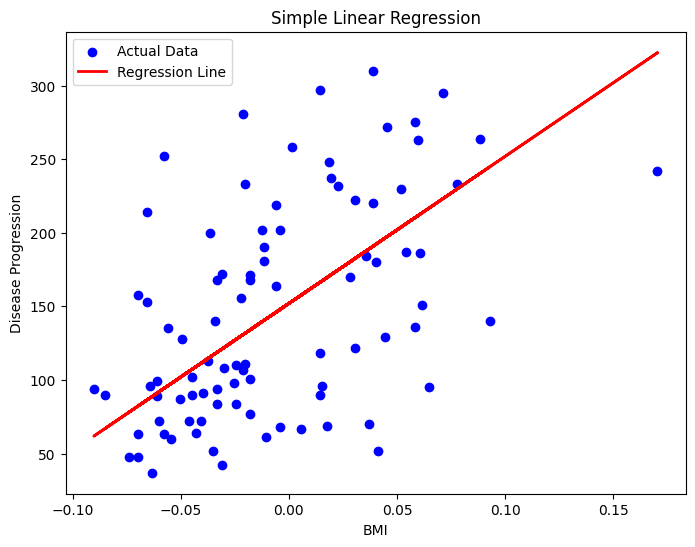

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


In [4]:
# Use all features
X_multi = df.drop('target', axis=1)
y_multi = df['target']

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Create model
model_multi = LinearRegression()

# Train model
model_multi.fit(X_train_m, y_train_m)

# Predictions
y_pred_m = model_multi.predict(X_test_m)

# Results
print("\nMulti-Linear Regression")
print("Coefficients:", model_multi.coef_)
print("Intercept:", model_multi.intercept_)
print("MSE:", mean_squared_error(y_test_m, y_pred_m))
print("R2 Score:", r2_score(y_test_m, y_pred_m))



Multi-Linear Regression
Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
Intercept: 151.34560453985995
MSE: 2900.193628493482
R2 Score: 0.4526027629719195


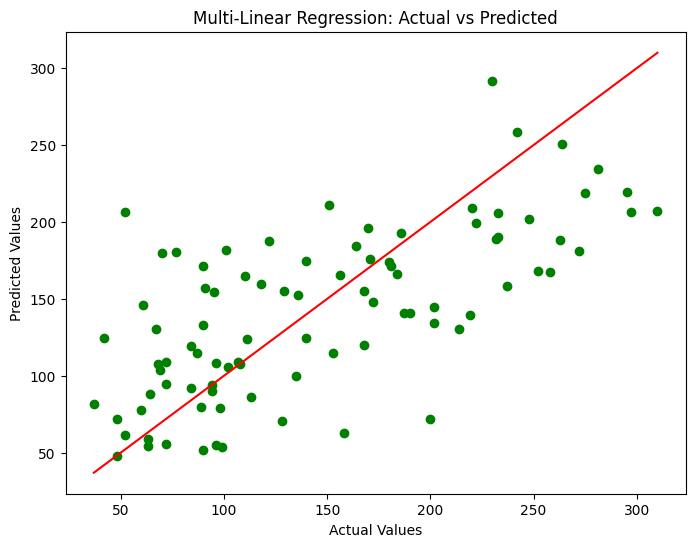

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_m, y_pred_m, color='green')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multi-Linear Regression: Actual vs Predicted")

# 45-degree reference line
plt.plot([y_test_m.min(), y_test_m.max()],
         [y_test_m.min(), y_test_m.max()],
         color='red')

plt.show()


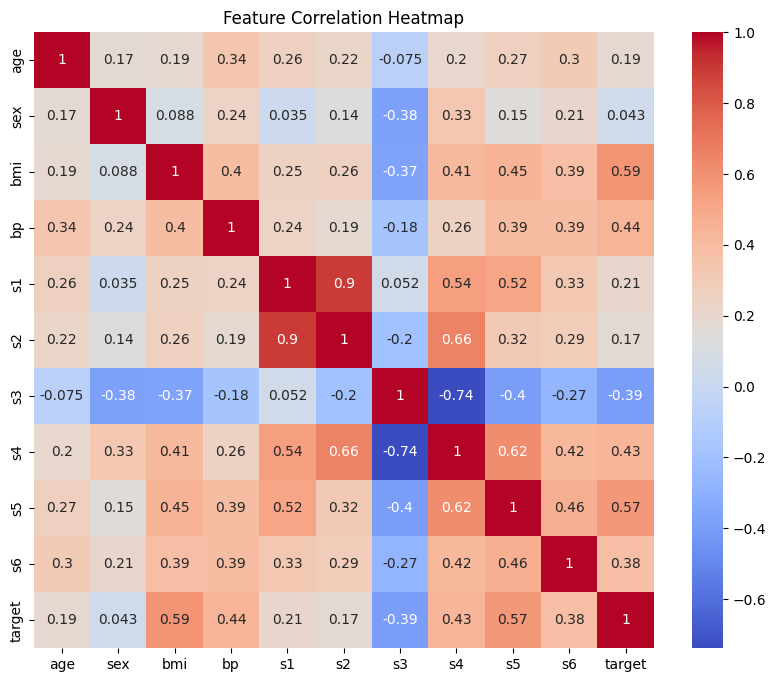

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()
